# SimpleQA Dataset Analysis

Clean rewrite using `llm_consistency.analysis` functions.

Swap `EXPERIMENT_FLAG` to run a different experiment without touching anything else.

In [1]:
DATASET         = "SimpleQA"
EXPERIMENT_FLAG = "v00"
# EXPERIMENT_FLAG = "rebut_v00_more_models"

## Imports

In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from llm_consistency.pipeline.consistency_alignment import load_aligned
from llm_consistency.analysis import (
    sort_with_my_logic,
    filter_ties,
    compute_agg_dist,
    compute_agg_maj,
    compute_mismatch_stats,
    compute_flip_stats,
    compute_A_any_stats,
)
from analysis_utils import df_to_acl_icml_table, prep_for_paper, prep, model_name_map

## Load aligned DataFrame

`load_aligned` returns the cached pkl from `run_artifacts/` if it exists, otherwise runs the full QA alignment pipeline (aggregate judges → filter → distributions → labels).

In [3]:
aligned = load_aligned(DATASET, EXPERIMENT_FLAG)
print(f"Shape: {aligned.shape}")
print(f"Models : {aligned.index.get_level_values('model').nunique()}")
print(f"Questions: {aligned.index.get_level_values('idx').nunique()}")
aligned.head(2)

Loading cached aligned verdicts from: /fs/nexus-scratch/kazemf/llm-consistency-empirical-study/run_artifacts/SimpleQA_v00/alignment/aligned_verdicts_SimpleQA_v00_both.pkl
Shape: (19747, 33)
Models : 19
Questions: 1129


,,correct_orig,incorrect_orig,not_attempted_orig,correct_para,incorrect_para,not_attempted_para,iid_mismatch_prob,distinct,mode_share,entropy,...,orig_label,orig_is_tie,orig_tied_labels,para_label,para_is_tie,para_tied_labels,both_label,both_is_tie,both_tied_labels,match
idx,model,,,,,,,,,,,,,,,,,,,,,
1,Qwen/Qwen2.5-7B-Instruct,False,False,True,0.000000,0.0,1.000000,0.000000,1,1.0,-0.000000,...,not_attempted,False,"(not_attempted,)",not_attempted,False,"(not_attempted,)",not_attempted,False,"(not_attempted,)",True
2,Qwen/Qwen2.5-7B-Instruct,False,True,False,0.333333,0.5,0.166667,0.611111,3,0.5,1.011404,...,incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",True


## Sanity checks

### Tie rates

A *tie* means two or more labels share the maximum probability in the paraphrase distribution. Ties are excluded from mismatch calculations.

In [4]:
rows = []
for subset in ["orig", "para", "both"]:
    labels = ["correct_", "incorrect_", "not_attempted_"]
    cols = [label + subset for label in labels]
    row_max = aligned[cols].max(axis=1)
    num_max = aligned[cols].eq(row_max, axis=0).sum(axis=1)
    rows.append({"subset": subset, "num_rows": len(aligned),
                 "num_ties": int((num_max > 1).sum()),
                 "tie_rate": f"{(num_max > 1).mean():.3%}"})
pd.DataFrame(rows).set_index("subset")

,num_rows,num_ties,tie_rate
subset,,,
orig,19747,0,0.000%
para,19747,964,4.882%
both,19747,735,3.722%


### Column overview

In [5]:
aligned.columns.tolist()

['correct_orig',
 'incorrect_orig',
 'not_attempted_orig',
 'correct_para',
 'incorrect_para',
 'not_attempted_para',
 'iid_mismatch_prob',
 'distinct',
 'mode_share',
 'entropy',
 'num_paraphrases',
 'normalized_entropy',
 'maj_value',
 'correct_both',
 'incorrect_both',
 'not_attempted_both',
 'iid_mismatch_prob_both',
 'distinct_both',
 'mode_share_both',
 'entropy_both',
 'num_paraphrases_both',
 'normalized_entropy_both',
 'maj_value_both',
 'orig_label',
 'orig_is_tie',
 'orig_tied_labels',
 'para_label',
 'para_is_tie',
 'para_tied_labels',
 'both_label',
 'both_is_tie',
 'both_tied_labels',
 'match']

## Table 1 — Distributional accuracy shifts

Per-model mean of per-question label distributions (fraction of paraphrases that were correct/incorrect/not_attempted).

In [6]:
agg_dist = compute_agg_dist(aligned)
agg_dist_sorted = sort_with_my_logic(agg_dist.reset_index())
agg_dist_sorted.round(3)

,model,correct_orig,correct_para,incorrect_orig,incorrect_para,not_attempted_orig,not_attempted_para,correct_diff,incorrect_diff,not_attempted_diff,N
0,gpt-3.5-turbo,0.094,0.075,0.378,0.285,0.528,0.639,-0.019,-0.093,0.112,1095
1,gpt-4.1,0.390,0.372,0.495,0.484,0.114,0.144,-0.018,-0.011,0.030,1086
2,gpt-4.1-mini,0.160,0.159,0.791,0.784,0.048,0.058,-0.002,-0.008,0.010,1078
3,gpt-4o,0.209,0.179,0.256,0.195,0.535,0.625,-0.030,-0.061,0.091,1098
4,meta-llama/Meta-Llama-3-8B-Instruct,0.039,0.035,0.397,0.421,0.564,0.544,-0.005,0.024,-0.020,1098
5,meta-llama/Llama-3.1-8B-Instruct,0.011,0.011,0.033,0.035,0.956,0.954,0.000,0.002,-0.002,1122
6,Qwen/Qwen2.5-7B-Instruct,0.004,0.005,0.025,0.026,0.971,0.969,0.000,0.001,-0.001,1126
7,Qwen/Qwen3-0.6B,0.000,0.000,0.100,0.040,0.900,0.959,0.000,-0.059,0.059,1113
8,Qwen/Qwen3-0.6B[with_thinking],0.008,0.004,0.610,0.529,0.382,0.466,-0.004,-0.080,0.084,963
9,Qwen/Qwen3-1.7B,0.010,0.009,0.378,0.314,0.612,0.677,-0.001,-0.065,0.066,1094


In [7]:
RENAME_DIST = {'correct_orig': 'A (Orig)', 'incorrect_orig': 'B (Orig)', 'not_attempted_orig': 'C (Orig)', 'correct_para': 'A (Para)', 'incorrect_para': 'B (Para)', 'not_attempted_para': 'C (Para)', 'correct_diff': '$\\Delta$A', 'incorrect_diff': '$\\Delta$B', 'not_attempted_diff': '$\\Delta$C', 'N': 'N'}
ORDER_DIST  = ['model', 'A (Orig)', 'B (Orig)', 'C (Orig)', 'A (Para)', 'B (Para)', 'C (Para)', '$\\Delta$A', '$\\Delta$B', '$\\Delta$C', 'N']

df_dist = prep(prep_for_paper(agg_dist_sorted, rename_map=RENAME_DIST, order_cols=ORDER_DIST))
print(df_to_acl_icml_table(
    df=df_dist,
    caption=f"Aggregate label-distribution shifts under paraphrasing ({DATASET}).",
    label=f"{DATASET.lower()}-dist-aggregate",
    short_model_names=model_name_map,
    col_format="l" + "c" * (df_dist.shape[1] - 1),
    full_width=True,
    color_negative_cols=[r"$\Delta$A"],
    bold_cells=lambda df: (
        ((df[r"$\Delta$A"].astype(float) < 0) & (df[r"$\Delta$A"].abs() > 1))
      | ((df[r"$\Delta$A"] == df[r"$\Delta$A"].max()) & (df[r"$\Delta$A"].abs() > 2))
    ),
))

\begin{table*}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccccccc}
\toprule
model & A (Orig) & B (Orig) & C (Orig) & A (Para) & B (Para) & C (Para) & $\Delta$A & $\Delta$B & $\Delta$C & N \\
\midrule
GPT-3.5 & 9.4 & 37.8 & 52.8 & 7.5 & 28.5 & 63.9 & \textcolor{red}{\textbf{-1.9}} & -9.3 & 11.2 & 1095 \\
GPT-4.1 & 39.0 & 49.5 & 11.4 & 37.2 & 48.4 & 14.4 & \textcolor{red}{\textbf{-1.8}} & -1.1 & 3.0 & 1086 \\
GPT-4.1-Mini & 16.0 & 79.1 & 4.8 & 15.9 & 78.4 & 5.8 & \textcolor{red}{-0.2} & -0.8 & 1.0 & 1078 \\
GPT-4o & 20.9 & 25.6 & 53.5 & 17.9 & 19.5 & 62.5 & \textcolor{red}{\textbf{-3.0}} & -6.1 & 9.1 & 1098 \\
LLaMA-3 8B & 3.9 & 39.7 & 56.4 & 3.5 & 42.1 & 54.4 & \textcolor{red}{-0.5} & 2.4 & -2.0 & 1098 \\
LLaMA-3.1 8B & 1.1 & 3.3 & 95.6 & 1.1 & 3.5 & 95.4 & 0.0 & 0.2 & -0.2 & 1122 \\
Qwen-2.5 7B & 0.4 & 2.5 & 97.1 & 0.5 & 2.6 & 96.9 & 0.0 & 0.1 & -0.1 & 1126 \\
Qwen-3 0.6B & 0.0 & 10.0 & 90.0 & 0.0 & 4.0 & 95.9 & 0.0 & -5.9 & 5.9 & 1113 \\
Qwen-3 0.6B +Thinking & 0.8 

## Table 2 — Majority-vote accuracy shifts

Each paraphrase produces a distribution; we take its majority-vote label and measure how often that vote matches the original-question label.

In [8]:
agg_maj = compute_agg_maj(aligned)
agg_maj_sorted = sort_with_my_logic(agg_maj.reset_index())
agg_maj_sorted.round(3)

,model,correct_orig,incorrect_orig,not_attempted_orig,correct_maj_vote,incorrect_maj_vote,not_attempted_maj_vote,correct_diff,incorrect_diff,not_attempted_diff,total_samples
0,gpt-3.5-turbo,0.094,0.378,0.528,0.081,0.291,0.627,-0.013,-0.087,0.100,1095
1,gpt-4.1,0.390,0.495,0.114,0.393,0.488,0.119,0.003,-0.007,0.005,1086
2,gpt-4.1-mini,0.160,0.791,0.048,0.171,0.792,0.037,0.010,0.001,-0.011,1078
3,gpt-4o,0.209,0.256,0.535,0.184,0.191,0.625,-0.026,-0.065,0.090,1098
4,meta-llama/Meta-Llama-3-8B-Instruct,0.039,0.397,0.564,0.038,0.439,0.523,-0.001,0.042,-0.041,1098
5,meta-llama/Llama-3.1-8B-Instruct,0.011,0.033,0.956,0.012,0.030,0.958,0.001,-0.003,0.002,1122
6,Qwen/Qwen2.5-7B-Instruct,0.004,0.025,0.971,0.003,0.019,0.979,-0.002,-0.006,0.008,1126
7,Qwen/Qwen3-0.6B,0.000,0.100,0.900,0.000,0.022,0.978,0.000,-0.077,0.077,1113
8,Qwen/Qwen3-0.6B[with_thinking],0.008,0.610,0.382,0.003,0.591,0.406,-0.005,-0.019,0.024,963
9,Qwen/Qwen3-1.7B,0.010,0.378,0.612,0.006,0.314,0.679,-0.004,-0.064,0.068,1094


In [9]:
RENAME_MAJ = {'correct_orig': 'A (Orig)', 'incorrect_orig': 'B (Orig)', 'not_attempted_orig': 'C (Orig)', 'correct_maj_vote': 'A (MV)', 'incorrect_maj_vote': 'B (MV)', 'not_attempted_maj_vote': 'C (MV)', 'correct_diff': '$\\Delta$A', 'incorrect_diff': '$\\Delta$B', 'not_attempted_diff': '$\\Delta$C', 'total_samples': 'N'}
ORDER_MAJ  = ['model', 'A (Orig)', 'B (Orig)', 'C (Orig)', 'A (MV)', 'B (MV)', 'C (MV)', '$\\Delta$A', '$\\Delta$B', '$\\Delta$C', 'N']

df_maj = prep(prep_for_paper(agg_maj_sorted, rename_map=RENAME_MAJ, order_cols=ORDER_MAJ))
print(df_to_acl_icml_table(
    df=df_maj,
    caption=f"Class-label shifts under paraphrasing ({DATASET}).",
    label=f"{DATASET.lower()}-dist-majority",
    short_model_names=model_name_map,
    col_format="l" + "c" * (df_maj.shape[1] - 1),
    full_width=True,
    color_negative_cols=[r"$\Delta$A"],
    bold_cells=lambda df: (
        ((df[r"$\Delta$A"].astype(float) < 0) & (df[r"$\Delta$A"].abs() > 1))
      | ((df[r"$\Delta$A"] == df[r"$\Delta$A"].max()) & (df[r"$\Delta$A"].abs() > 2))
    ),
))

\begin{table*}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccccccc}
\toprule
model & A (Orig) & B (Orig) & C (Orig) & A (MV) & B (MV) & C (MV) & $\Delta$A & $\Delta$B & $\Delta$C & N \\
\midrule
GPT-3.5 & 9.4 & 37.8 & 52.8 & 8.1 & 29.1 & 62.7 & \textcolor{red}{\textbf{-1.3}} & -8.7 & 10.0 & 1095 \\
GPT-4.1 & 39.0 & 49.5 & 11.4 & 39.3 & 48.8 & 11.9 & 0.3 & -0.7 & 0.5 & 1086 \\
GPT-4.1-Mini & 16.0 & 79.1 & 4.8 & 17.1 & 79.2 & 3.7 & 1.0 & 0.1 & -1.1 & 1078 \\
GPT-4o & 20.9 & 25.6 & 53.5 & 18.4 & 19.1 & 62.5 & \textcolor{red}{\textbf{-2.6}} & -6.5 & 9.0 & 1098 \\
LLaMA-3 8B & 3.9 & 39.7 & 56.4 & 3.8 & 43.9 & 52.3 & \textcolor{red}{-0.1} & 4.2 & -4.1 & 1098 \\
LLaMA-3.1 8B & 1.1 & 3.3 & 95.6 & 1.2 & 3.0 & 95.8 & 0.1 & -0.3 & 0.2 & 1122 \\
Qwen-2.5 7B & 0.4 & 2.5 & 97.1 & 0.3 & 1.9 & 97.9 & \textcolor{red}{-0.2} & -0.6 & 0.8 & 1126 \\
Qwen-3 0.6B & 0.0 & 10.0 & 90.0 & 0.0 & 2.2 & 97.8 & 0.0 & -7.7 & 7.7 & 1113 \\
Qwen-3 0.6B +Thinking & 0.8 & 61.0 & 38.2 & 0.3 & 59.1 & 40.6

## Table 3 — Accuracy + mismatch combined

In [10]:
mismatch_stats = compute_mismatch_stats(aligned)
mismatch_stats.round(3)

,total_samples,num_mismatches,mismatch_rate,iid_mismatch_prob,normalized_entropy,mode_share
model,,,,,,
Qwen/Qwen2.5-7B-Instruct,1126,22,0.020,0.026,0.021,0.981
Qwen/Qwen3-0.6B,1113,104,0.093,0.049,0.043,0.967
Qwen/Qwen3-0.6B[with_thinking],963,286,0.297,0.262,0.240,0.795
Qwen/Qwen3-1.7B,1094,254,0.232,0.240,0.202,0.819
Qwen/Qwen3-1.7B[with_thinking],914,144,0.158,0.178,0.175,0.864
Qwen/Qwen3-14B,1064,184,0.173,0.198,0.170,0.851
Qwen/Qwen3-14B[with_thinking],928,198,0.213,0.192,0.176,0.855
Qwen/Qwen3-32B,1076,173,0.161,0.189,0.161,0.860
Qwen/Qwen3-32B[with_thinking],911,208,0.228,0.218,0.206,0.833


In [11]:
# Join distributional accuracy with mismatch/entropy stats
acc_base = agg_dist_sorted[["model", "correct_orig", "correct_para", "correct_diff", "N"]].copy()
combined = sort_with_my_logic(acc_base.merge(mismatch_stats.reset_index(), on="model"))

RENAME_COMBINED = {
    "correct_orig":   "Orig Acc",
    "correct_para":   "Para Acc",
    "correct_diff":   r"$\Delta$Acc",
    "mismatch_rate":  r"Mismatch (\%)",
    "iid_mismatch_prob": "IID-Mismatch",
    "normalized_entropy": "Entropy",
    "mode_share":     r"Mode Share (\%)",
    "N": "N",
}
ORDER_COMBINED = [
    "model", "Orig Acc", "Para Acc", r"$\Delta$Acc",
    r"Mismatch (\%)", "IID-Mismatch", "Entropy", r"Mode Share (\%)", "N"
]

df_combined = prep(
    prep_for_paper(combined, rename_map=RENAME_COMBINED, order_cols=ORDER_COMBINED),
    ignore_pct_col_pats=["entropy", "iid"],
)
print(df_to_acl_icml_table(
    df=df_combined,
    caption=f"Accuracy degradation and instability under paraphrasing ({DATASET}).",
    label=f"{DATASET.lower()}-acc-mismatch-combined",
    short_model_names=model_name_map,
    col_format="l" + "c" * (len(ORDER_COMBINED) - 1),
    full_width=True,
    custom_float_format=True,
    bold_negative_cols=[r"$\Delta$Acc"],
    bold_cells=lambda df: pd.DataFrame({
        "IID-Mismatch": (
            (df["IID-Mismatch"].astype(float) >= 0.1)
            | (df["IID-Mismatch"] == df["IID-Mismatch"].max())
        ),
        "Entropy": (
            (df["Entropy"].astype(float) >= 0.1)
            | (df["Entropy"] == df["Entropy"].max())
        ),
        r"Mismatch (\%)": df[r"Mismatch (\%)"] >= 10,
    }, index=df.index),
))

\begin{table*}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccccc}
\toprule
model & Orig Acc & Para Acc & $\Delta$Acc & Mismatch (\%) & IID-Mismatch & Entropy & Mode Share (\%) & N \\
\midrule
GPT-3.5 & 9.4 & 7.5 & \textbf{-1.9} & \textbf{22.8} & \textbf{0.21} & \textbf{0.18} & 84.0 & 1095 \\
GPT-4.1 & 39.0 & 37.2 & \textbf{-1.8} & \textbf{14.5} & \textbf{0.16} & \textbf{0.14} & 88.0 & 1086 \\
GPT-4.1-Mini & 16.0 & 15.9 & \textbf{-0.2} & 8.8 & \textbf{0.1} & 0.09 & 92.3 & 1078 \\
GPT-4o & 20.9 & 17.9 & \textbf{-3.0} & \textbf{19.6} & \textbf{0.18} & \textbf{0.15} & 86.4 & 1098 \\
LLaMA-3 8B & 3.9 & 3.5 & \textbf{-0.5} & \textbf{17.0} & \textbf{0.17} & \textbf{0.15} & 87.0 & 1098 \\
LLaMA-3.1 8B & 1.1 & 1.1 & 0.0 & 2.9 & 0.03 & 0.02 & 98.1 & 1122 \\
Qwen-2.5 7B & 0.4 & 0.5 & 0.0 & 2.0 & 0.03 & 0.02 & 98.1 & 1126 \\
Qwen-3 0.6B & 0.0 & 0.0 & 0.0 & 9.3 & 0.05 & 0.04 & 96.7 & 1113 \\
Qwen-3 0.6B +Thinking & 0.8 & 0.4 & \textbf{-0.4} & \textbf{29.7} & \textbf{0.26} & \textb

## Table 4 — Directional flip rates

Conditional rates: how often does the majority-vote paraphrase label differ from the original label, split by which direction the flip goes? `A` = correct, `notA` = incorrect or not_attempted. `ND` (non-determinism) = mode_share < 1.

In [12]:
df_flip = compute_flip_stats(aligned)
df_flip = sort_with_my_logic(df_flip)
df_flip.round(2)

,model,Orig_Acc,reliable_A,A_to_notA,notA_to_A,A_to_ND,notA_to_ND,ND
0,gpt-3.5-turbo,9.41,2.01,37.86,2.52,80.58,48.79,51.78
1,gpt-4.1,39.04,23.94,11.79,8.01,37.97,43.81,41.53
2,gpt-4.1-mini,16.05,8.07,16.18,4.31,47.40,25.08,28.66
3,gpt-4o,20.95,7.19,30.00,4.72,64.35,42.74,47.27
4,meta-llama/Meta-Llama-3-8B-Instruct,3.92,0.91,30.23,1.14,76.74,44.74,45.99
5,meta-llama/Llama-3.1-8B-Instruct,1.07,0.27,25.00,0.36,66.67,6.94,7.58
6,Qwen/Qwen2.5-7B-Instruct,0.44,0.09,40.00,0.00,80.00,6.87,7.19
7,Qwen/Qwen3-0.6B,0.00,0.00,NaN,0.00,NaN,16.17,16.17
8,Qwen/Qwen3-0.6B[with_thinking],0.83,0.00,75.00,0.10,87.50,66.60,66.77
9,Qwen/Qwen3-1.7B,1.01,0.27,72.73,0.37,54.55,63.53,63.44


In [13]:
RENAME_FLIP = {'Orig_Acc': '$P(A_{\\text{orig}})$', 'reliable_A': '$P(A_{\\text{strict}})$', 'A_to_notA': '$P(\\neg A_{\\text{para}} \\mid A_{\\text{orig}})$', 'notA_to_A': '$P(A_{\\text{para}} \\mid \\neg A_{\\text{orig}})$', 'A_to_ND': '$P(\\text{ND} \\mid A_{\\text{orig}})$', 'notA_to_ND': '$P(\\text{ND} \\mid \\neg A_{\\text{orig}})$'}

# ND kept in raw table above; drop for paper (per original notebook)
df_flip_paper = sort_with_my_logic(
    df_flip.fillna(0.0).drop(columns=["ND"], errors="ignore")
)
df_flip_paper = prep(prep_for_paper(df_flip_paper, rename_map=RENAME_FLIP))
print(df_to_acl_icml_table(
    df=df_flip_paper,
    caption=f"Directional flip rates and nondeterminism under paraphrasing ({DATASET}).",
    label=f"{DATASET.lower()}-flip-nd",
    short_model_names=model_name_map,
    col_format="l" + "c" * (df_flip_paper.shape[1] - 1),
    full_width=True,
    max_header_len=100,
))

\begin{table*}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccc}
\toprule
model & $P(A_{\text{orig}})$ & $P(A_{\text{strict}})$ & $P(\neg A_{\text{para}} \mid A_{\text{orig}})$ & $P(A_{\text{para}} \mid \neg A_{\text{orig}})$ & $P(\text{ND} \mid A_{\text{orig}})$ & $P(\text{ND} \mid \neg A_{\text{orig}})$ \\
\midrule
GPT-3.5 & 9.4 & 2.0 & 37.9 & 2.5 & 80.6 & 48.8 \\
GPT-4.1 & 39.0 & 23.9 & 11.8 & 8.0 & 38.0 & 43.8 \\
GPT-4.1-Mini & 16.0 & 8.1 & 16.2 & 4.3 & 47.4 & 25.1 \\
GPT-4o & 20.9 & 7.2 & 30.0 & 4.7 & 64.3 & 42.7 \\
LLaMA-3 8B & 3.9 & 0.9 & 30.2 & 1.1 & 76.7 & 44.7 \\
LLaMA-3.1 8B & 1.1 & 0.3 & 25.0 & 0.4 & 66.7 & 6.9 \\
Qwen-2.5 7B & 0.4 & 0.1 & 40.0 & 0.0 & 80.0 & 6.9 \\
Qwen-3 0.6B & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 & 16.2 \\
Qwen-3 0.6B +Thinking & 0.8 & 0.0 & 75.0 & 0.1 & 87.5 & 66.6 \\
Qwen-3 1.7B & 1.0 & 0.3 & 72.7 & 0.4 & 54.5 & 63.5 \\
Qwen-3 1.7B +Thinking & 1.3 & 0.3 & 41.7 & 0.4 & 58.3 & 46.7 \\
Qwen-3 4B & 2.0 & 0.5 & 42.9 & 0.9 & 76.2 & 57.5 \\
Qwen-3 4B 

## Table 5 — "Any-correct" statistics

`A_any` = at least one paraphrase produced a correct answer. This measures latent knowledge that the model cannot reliably access.

In [14]:
df_Aany = (
    aligned.groupby("model")
           .apply(compute_A_any_stats)
           .reset_index()
)
df_Aany = sort_with_my_logic(df_Aany)
df_Aany.round(2)

,model,Orig_Acc,Para_Acc,A_any_all,reliable_A,A_any_given_origWrong,A_any_given_paraWrong
0,gpt-3.5-turbo,9.41,7.53,15.89,2.01,8.27,8.45
1,gpt-4.1,39.04,37.19,50.18,23.94,21.15,17.91
2,gpt-4.1-mini,16.05,15.86,24.30,8.07,10.50,8.72
3,gpt-4o,20.95,17.94,32.51,7.19,17.17,17.30
4,meta-llama/Meta-Llama-3-8B-Instruct,3.92,3.46,7.65,0.91,4.27,3.98
5,meta-llama/Llama-3.1-8B-Instruct,1.07,1.09,2.76,0.27,1.80,1.62
6,Qwen/Qwen2.5-7B-Instruct,0.44,0.45,1.51,0.09,1.07,1.25
7,Qwen/Qwen3-0.6B,0.00,0.03,0.27,0.00,0.27,0.27
8,Qwen/Qwen3-0.6B[with_thinking],0.83,0.42,1.35,0.00,1.05,1.04
9,Qwen/Qwen3-1.7B,1.01,0.88,2.47,0.27,1.94,1.84


In [15]:
RENAME_AANY = {'Orig_Acc': '$P(A_{\\text{orig}})$', 'Para_Acc': '$P(A_{\\text{para}})$', 'reliable_A': '$P(A_{\\text{strict}})$', 'A_any_all': '$P(A_{\\text{any}})$', 'A_any_given_origWrong': '$P(A_{\\text{any}} \\mid \\neg A_{\\text{orig}})$'}

df_Aany_paper = sort_with_my_logic(
    df_Aany.drop(columns=["A_any_given_paraWrong"], errors="ignore").fillna(0.0)
)
df_Aany_paper = prep(prep_for_paper(df_Aany_paper, rename_map=RENAME_AANY))
print(df_to_acl_icml_table(
    df=df_Aany_paper,
    caption=f'Partial-correctness ("any-correct") statistics under paraphrasing ({DATASET}).',
    label=f"{DATASET.lower()}-anycorrect",
    short_model_names=model_name_map,
    col_format="l" + "c" * (df_Aany_paper.shape[1] - 1),
    full_width=True,
    max_header_len=100,
    resize=False,
))

\begin{table*}[t]
\centering
\begin{tabular}{lccccc}
\toprule
model & $P(A_{\text{orig}})$ & $P(A_{\text{para}})$ & $P(A_{\text{any}})$ & $P(A_{\text{strict}})$ & $P(A_{\text{any}} \mid \neg A_{\text{orig}})$ \\
\midrule
GPT-3.5 & 9.4 & 7.5 & 15.9 & 2.0 & 8.3 \\
GPT-4.1 & 39.0 & 37.2 & 50.2 & 23.9 & 21.1 \\
GPT-4.1-Mini & 16.0 & 15.9 & 24.3 & 8.1 & 10.5 \\
GPT-4o & 20.9 & 17.9 & 32.5 & 7.2 & 17.2 \\
LLaMA-3 8B & 3.9 & 3.5 & 7.7 & 0.9 & 4.3 \\
LLaMA-3.1 8B & 1.1 & 1.1 & 2.8 & 0.3 & 1.8 \\
Qwen-2.5 7B & 0.4 & 0.5 & 1.5 & 0.1 & 1.1 \\
Qwen-3 0.6B & 0.0 & 0.0 & 0.3 & 0.0 & 0.3 \\
Qwen-3 0.6B +Thinking & 0.8 & 0.4 & 1.3 & 0.0 & 1.0 \\
Qwen-3 1.7B & 1.0 & 0.9 & 2.5 & 0.3 & 1.9 \\
Qwen-3 1.7B +Thinking & 1.3 & 1.7 & 5.1 & 0.3 & 4.2 \\
Qwen-3 4B & 2.0 & 1.8 & 4.9 & 0.5 & 3.5 \\
Qwen-3 4B +Thinking & 2.0 & 1.8 & 4.6 & 0.5 & 3.2 \\
Qwen-3 8B & 3.0 & 2.1 & 5.5 & 0.5 & 3.5 \\
Qwen-3 8B +Thinking & 2.5 & 2.2 & 4.9 & 0.6 & 3.1 \\
Qwen-3 14B & 5.2 & 3.9 & 8.4 & 1.1 & 3.9 \\
Qwen-3 14B +Thinking & 3.2

## Escape mass analysis

For each (idx, model) pair, the *escape mass* is the probability that a random paraphrase produces a *different* label than the anchor. Three anchors:

- **Decision anchor**: anchor = original-question label (how often does paraphrasing escape the model's original decision?)
- **GT anchor**: anchor = correct (how often does paraphrasing escape the ground-truth label?)
- **Best-case fallback**: anchor = correct if any paraphrase was correct, else decision anchor

In [16]:
LABELS = ["correct", "incorrect", "not_attempted"]
P = aligned[[f"{l}_para" for l in LABELS]].copy()

# Vectorised: pick p(anchor_label) for each row
label_to_col = {l: f"{l}_para" for l in LABELS}
anchor_col   = aligned["orig_label"].map(label_to_col)
col_to_i     = {c: i for i, c in enumerate(P.columns)}
p_anchor = P.to_numpy()[np.arange(len(P)), anchor_col.map(col_to_i).to_numpy()]

aligned["escape_decision"]         = 1.0 - p_anchor
aligned["escape_gt"]               = 1.0 - P["correct_para"].to_numpy()
aligned["latent_correct_exists"]   = P["correct_para"].to_numpy() > 0
aligned["escape_bestcase_fallback"] = np.where(
    aligned["latent_correct_exists"],
    1.0 - P["correct_para"].to_numpy(),
    aligned["escape_decision"].to_numpy(),
)

ESCAPE_METRICS = [
    ("Decision anchor",    "escape_decision"),
    ("GT anchor (correct)", "escape_gt"),
    ("Best-case fallback",  "escape_bestcase_fallback"),
]
escape_cols = [col for _, col in ESCAPE_METRICS]
aligned[escape_cols].describe().round(3)

,escape_decision,escape_gt,escape_bestcase_fallback
count,19747.000,19747.000,19747.000
mean,0.210,0.941,0.221
std,0.293,0.203,0.303
min,0.000,0.000,0.000
25%,0.000,1.000,0.000
50%,0.000,1.000,0.000
75%,0.333,1.000,0.400
max,1.000,1.000,1.000


### Per-model escape distributions

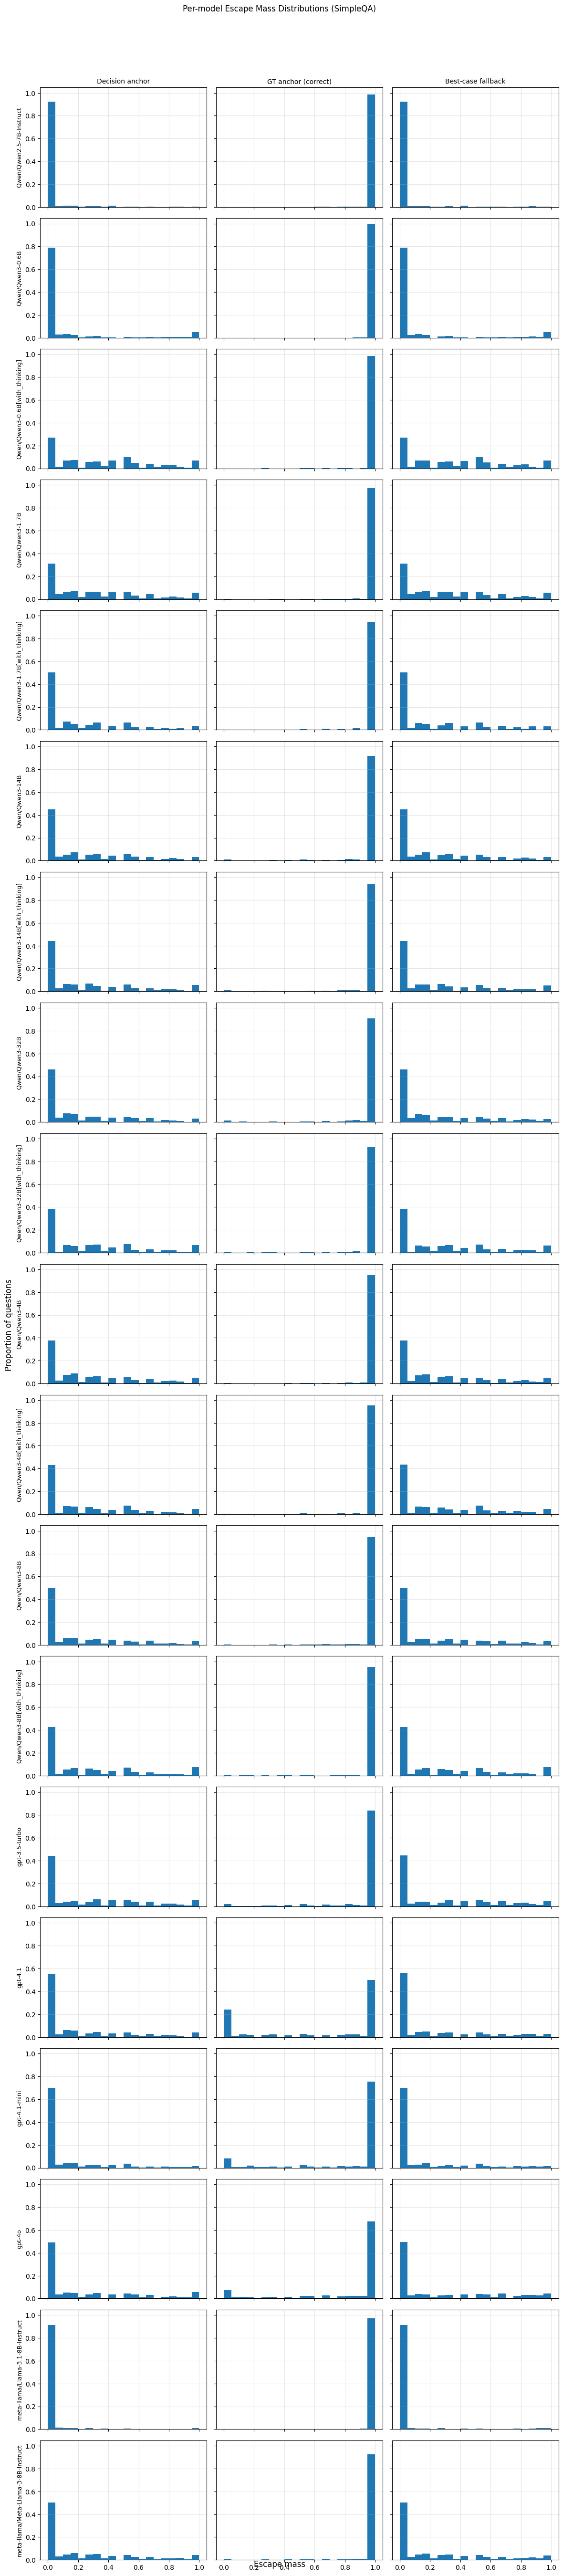

In [17]:
# plot_escape_histograms_per_model: defined inline here (not yet in src/analysis/plotting.py)
def plot_escape_histograms_per_model(
    df, model_col="model", metrics=ESCAPE_METRICS, bins=np.linspace(0, 1, 21)
):
    models    = sorted(df.reset_index()[model_col].unique())
    n_models  = len(models)
    n_metrics = len(metrics)
    fig, axes = plt.subplots(
        n_models, n_metrics,
        figsize=(4 * n_metrics, 2.8 * n_models),
        sharex=True, sharey=True,
    )
    if n_models == 1:  axes = axes[np.newaxis, :]
    if n_metrics == 1: axes = axes[:, np.newaxis]
    df_flat = df.reset_index()
    for i, m in enumerate(models):
        df_m = df_flat[df_flat[model_col] == m]
        for j, (title, col) in enumerate(metrics):
            ax   = axes[i, j]
            vals = df_m[col].dropna().to_numpy()
            if len(vals) == 0:
                ax.text(0.5, 0.5, 'n/a', ha='center', va='center')
                ax.set_axis_off()
                continue
            ax.hist(vals, bins=bins, weights=np.ones_like(vals) / len(vals))
            if i == 0: ax.set_title(title, fontsize=10)
            if j == 0: ax.set_ylabel(m, fontsize=9)
            ax.grid(True, alpha=0.3)
    fig.supxlabel('Escape mass')
    fig.supylabel('Proportion of questions')
    fig.suptitle(f'Per-model Escape Mass Distributions ({DATASET})', y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

plot_escape_histograms_per_model(aligned)

### Per-model mean escape

In [18]:
aligned.groupby("model")[escape_cols]\
       .mean()\
       .sort_values("escape_decision", ascending=False)\
       .round(3)

,escape_decision,escape_gt,escape_bestcase_fallback
model,,,
Qwen/Qwen3-0.6B[with_thinking],0.350,0.996,0.352
Qwen/Qwen3-1.7B,0.299,0.991,0.302
Qwen/Qwen3-32B[with_thinking],0.284,0.966,0.298
Qwen/Qwen3-4B,0.272,0.982,0.283
Qwen/Qwen3-8B[with_thinking],0.271,0.978,0.278
gpt-3.5-turbo,0.270,0.925,0.282
Qwen/Qwen3-4B[with_thinking],0.251,0.982,0.260
Qwen/Qwen3-14B[with_thinking],0.251,0.973,0.259
gpt-4o,0.239,0.821,0.270


## U-curve: instability vs per-question accuracy

For each (idx, model) row, `correct_para` is the fraction of paraphrases that were correct and `iid_mismatch_prob` is the per-question instability. Binning by `correct_para` reveals whether instability peaks at intermediate accuracy levels.

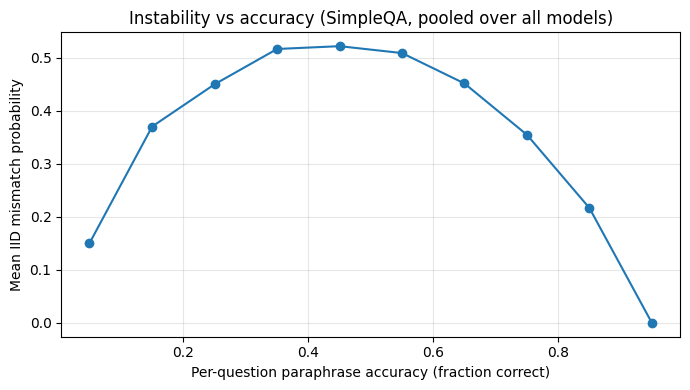

In [19]:
df_q = aligned.reset_index()[
    ["model", "correct_para", "iid_mismatch_prob", "normalized_entropy"]
].copy()
bins_acc = np.linspace(0, 1, 11)
df_q["acc_bin"] = pd.cut(df_q["correct_para"].astype(float), bins=bins_acc, include_lowest=True)

# Pooled curve across all models
curve = df_q.groupby("acc_bin")["iid_mismatch_prob"].mean().reset_index()
curve["bin_center"] = curve["acc_bin"].apply(lambda x: (x.left + x.right) / 2)

plt.figure(figsize=(7, 4))
plt.plot(curve["bin_center"], curve["iid_mismatch_prob"], marker="o")
plt.xlabel("Per-question paraphrase accuracy (fraction correct)")
plt.ylabel("Mean IID mismatch probability")
plt.title(f"Instability vs accuracy ({DATASET}, pooled over all models)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

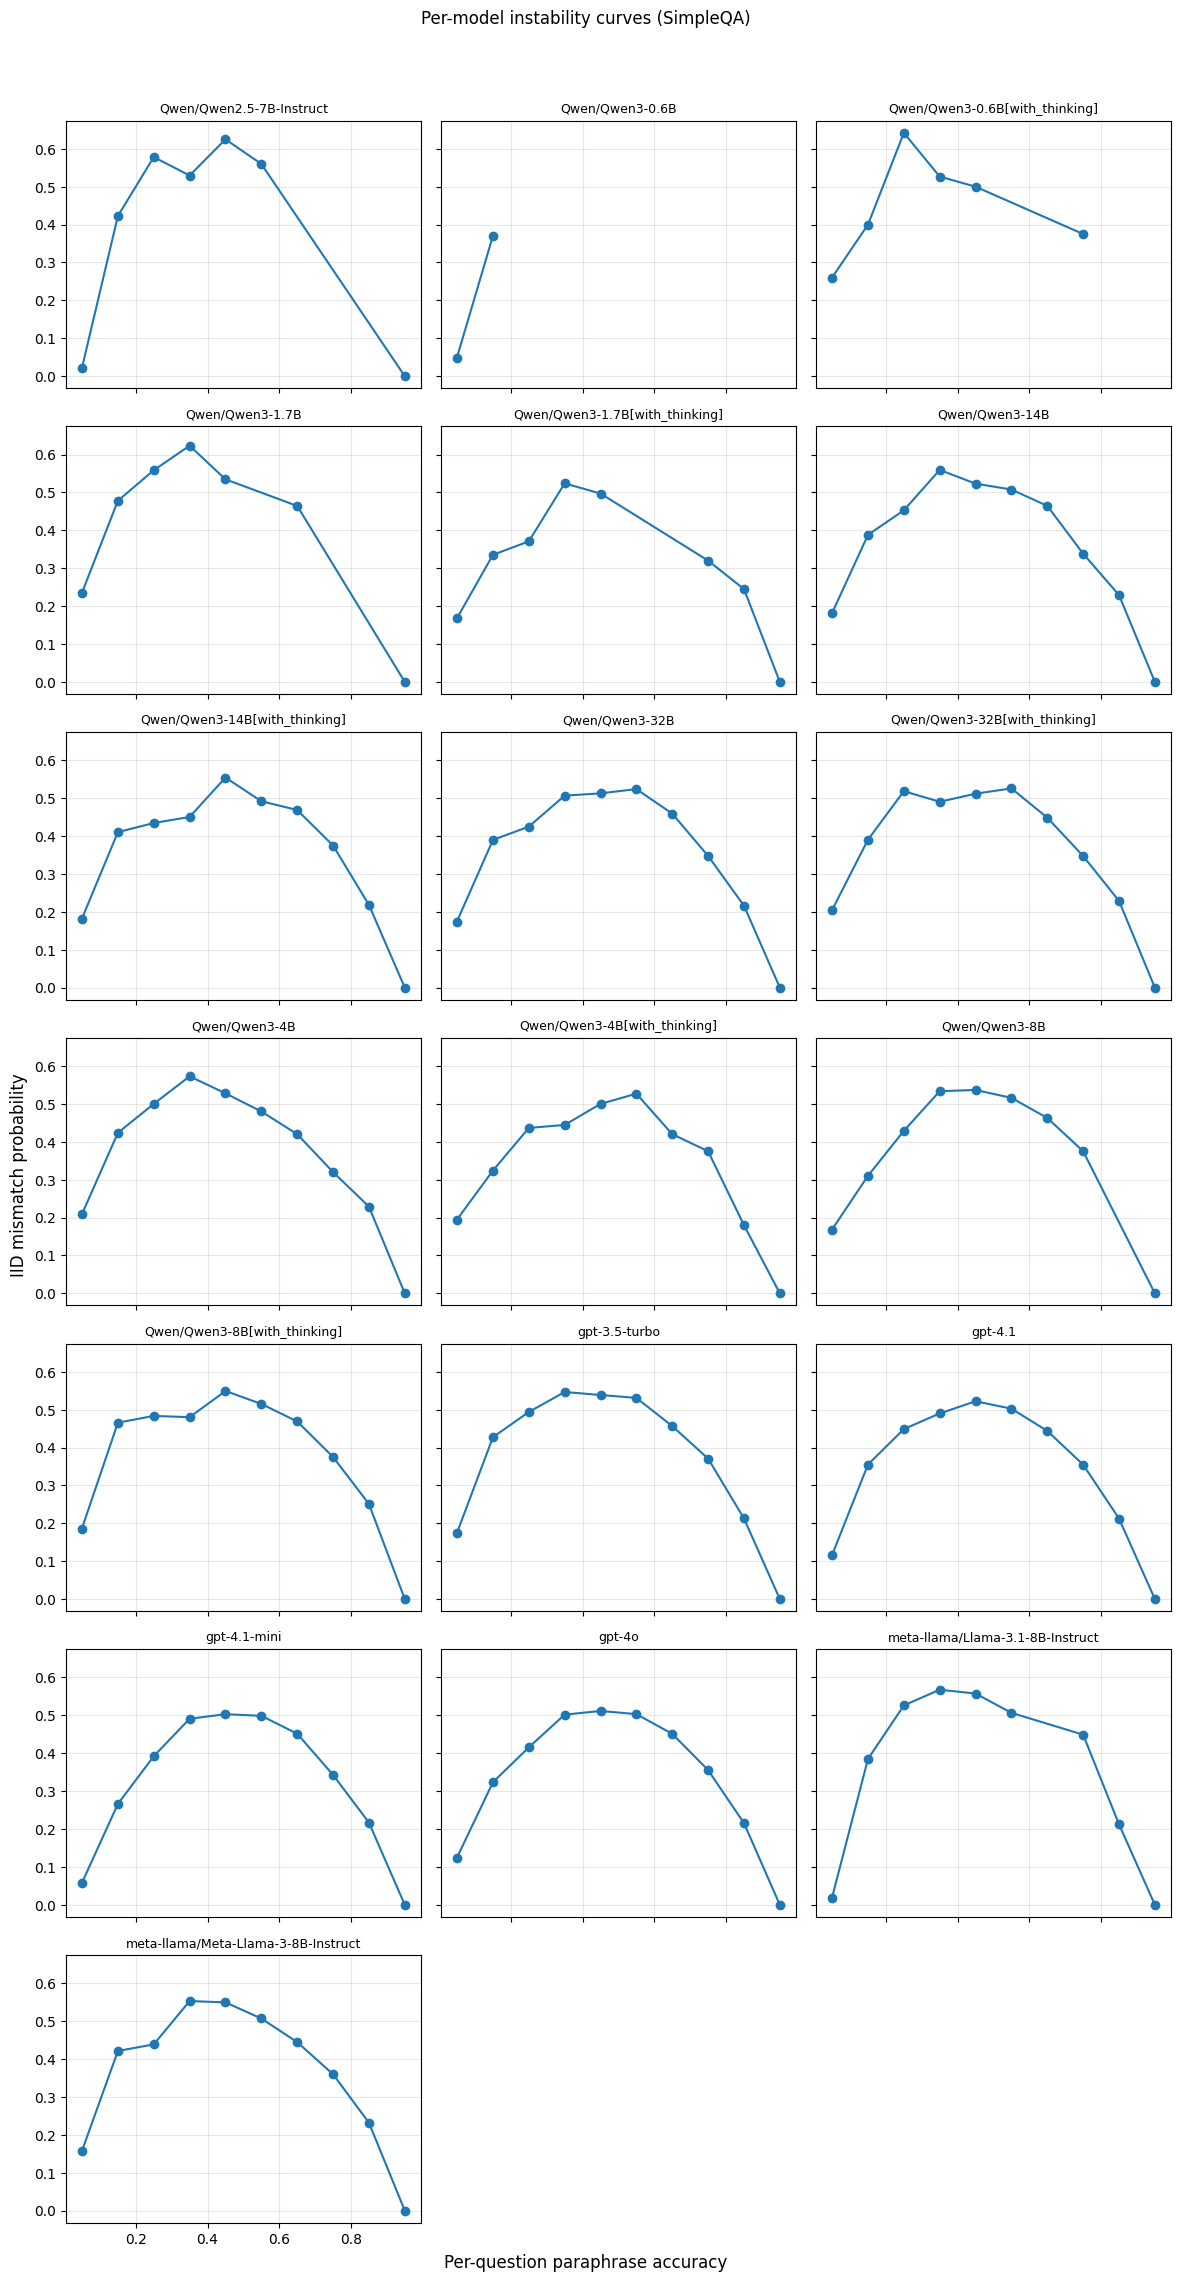

In [20]:
# Per-model version
models = sorted(df_q["model"].unique())
ncols  = 3
nrows  = math.ceil(len(models) / ncols)

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(4 * ncols, 3.2 * nrows),
                          sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for ax, m in zip(axes, models):
    sub   = df_q[df_q["model"] == m]
    curve = sub.groupby("acc_bin")["iid_mismatch_prob"].mean().reset_index()
    curve["bin_center"] = curve["acc_bin"].apply(lambda x: (x.left + x.right) / 2)
    ax.plot(curve["bin_center"], curve["iid_mismatch_prob"], marker="o")
    ax.set_title(m, fontsize=9)
    ax.grid(alpha=0.3)

for j in range(len(models), len(axes)):
    axes[j].axis("off")

fig.supxlabel("Per-question paraphrase accuracy")
fig.supylabel("IID mismatch probability")
fig.suptitle(f"Per-model instability curves ({DATASET})", y=1.02)
plt.tight_layout()
plt.show()

## Visualizations

### Reliable vs Expected vs Best-case accuracy

Sorted by original accuracy (ascending). The horizontal bar spans from `reliable_A` (strict: all paraphrases correct) to `A_any_all` (best-case: any paraphrase correct). The red `X` marks the expected (average) paraphrase accuracy.

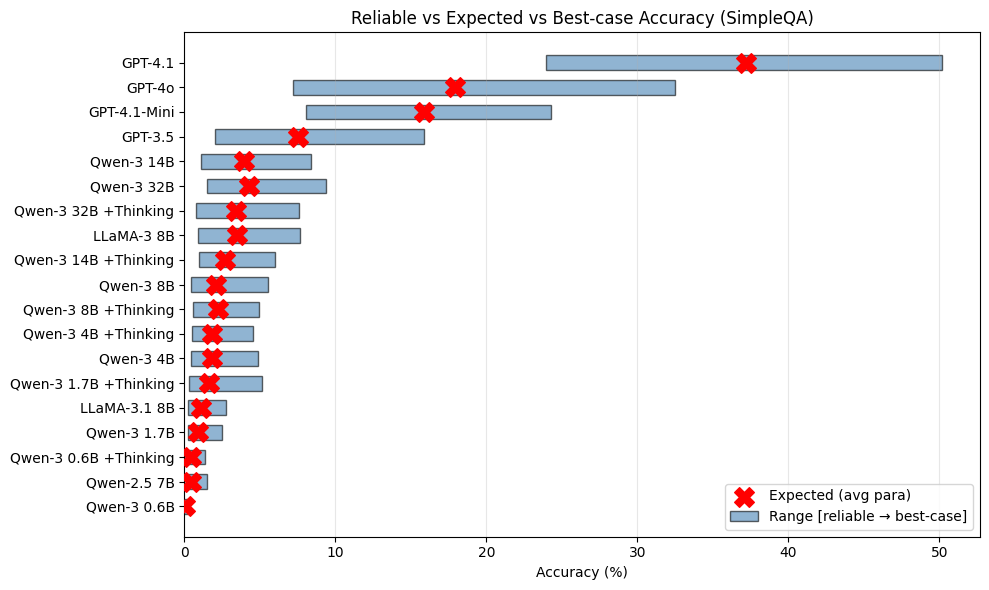

In [21]:
def _short(m):
    return model_name_map.get(m, m.split("/")[-1])

plot3 = df_Aany.copy().sort_values("Orig_Acc", ascending=True)
y = np.arange(len(plot3))

plt.figure(figsize=(10, 6))
plt.barh(y, plot3["A_any_all"].values - plot3["reliable_A"].values,
         left=plot3["reliable_A"].values,
         height=0.6, alpha=0.6, color="steelblue", edgecolor="black",
         label="Range [reliable → best-case]")
plt.scatter(plot3["Para_Acc"].values, y, marker="X", s=200, color="red",
            zorder=5, label="Expected (avg para)")
plt.yticks(y, [_short(m) for m in plot3["model"]])
plt.xlabel("Accuracy (%)")
plt.title(f"Reliable vs Expected vs Best-case Accuracy ({DATASET})")
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Flip rate bar chart

For each model (sorted by original accuracy), the three bars show: fragility (correct → wrong), recoverability (wrong → correct), and non-determinism (paraphrases disagree).

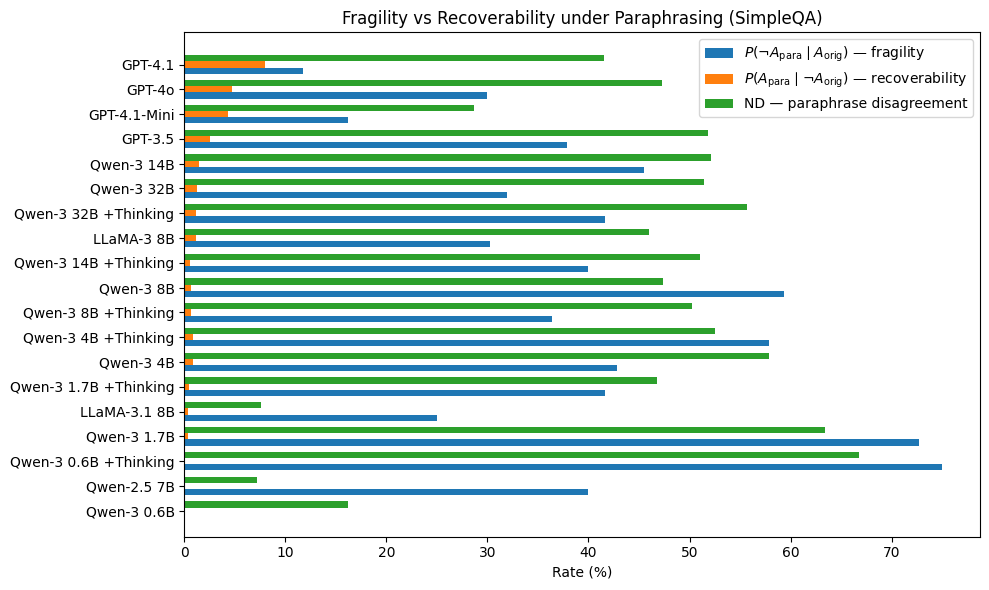

In [22]:
plot4 = sort_with_my_logic(df_flip).sort_values("Orig_Acc", ascending=True)
y = np.arange(len(plot4))
h = 0.25

plt.figure(figsize=(10, 6))
plt.barh(y - h, plot4["A_to_notA"].values, height=h,
         label=r'$P(\neg A_\text{para} \mid A_\text{orig})$ — fragility')
plt.barh(y,     plot4["notA_to_A"].values,  height=h,
         label=r'$P(A_\text{para} \mid \neg A_\text{orig})$ — recoverability')
plt.barh(y + h, plot4["ND"].values,          height=h,
         label="ND — paraphrase disagreement")
plt.yticks(y, [_short(m) for m in plot4["model"]])
plt.xlabel("Rate (%)")
plt.title(f"Fragility vs Recoverability under Paraphrasing ({DATASET})")
plt.legend()
plt.tight_layout()
plt.show()